# Teoria da Computação — Trabalho Prático
## Implementação e Demonstração de Autômato Finito

**Disciplina:** Teoria da Computação  
**Professor:** Joel dos Santos  
**Grupo 3**  
Ennya Gomes
Matheus Carvalho
Pedro Henrique
**Linguagem escolhida:** Reconhecimento de Números em múltiplas notações  
**Prazo de entrega:** 26/04/2026

---
# 1. Introdução

## 1.1 Linguagem Escolhida

A linguagem alvo deste trabalho é o conjunto de todas as cadeias que representam
**números válidos** em uma das cinco notações a seguir:

| Notação | Exemplos |
|---|---|
| **Inteiros** (com sinal opcional) | `123`, `-456`, `+789` |
| **Reais / Ponto Flutuante** | `3.14`, `-0.5`, `.5`, `5.` |
| **Notação Científica** | `1.23e4`, `-5E-10`, `.5e3`, `2.e-2` |
| **Hexadecimal** (prefixo `0x`, `#` ou sufixo `h`) | `0xFF`, `#1A3`, `FFh` |
| **Complexos** | `3+4i`, `2.5-1.3i`, `-1+0i` |

## 1.2 Motivação

O reconhecimento de literais numéricos é uma das primeiras etapas de qualquer
compilador ou interpretador de linguagens de programação (fase de *lexing*).
Modelar esse problema como um Autômato Finito permite:

- Verificação formal de corretude;
- Implementação eficiente em O(n) no tamanho da entrada;
- Base para geradores de scanners automáticos (como Flex/Lex).

---
# 2. Definição do Problema

## 2.1 Informações Armazenadas nos Estados

Cada estado do autômato codifica **o que já foi lido** da entrada. As informações
relevantes são:

- Se um sinal `+`/`-` foi lido;
- Se dígitos decimais foram lidos (parte inteira);
- Se o ponto decimal `.` foi lido;
- Se dígitos fracionários foram lidos;
- Se `e` ou `E` foi lido (início de expoente);
- Se o expoente tem sinal;
- Se dígitos do expoente foram lidos;
- Se o prefixo `0x` ou `#` foi lido (hexadecimal);
- Se o sufixo `h` pode encerrar a entrada como hexadecimal;
- Se a parte real de um complexo foi completada;
- Se o separador `+`/`-` entre parte real e imaginária foi lido;
- Se a parte imaginária foi lida e se `i` foi lido ao final.

## 2.2 Representação Formal da Linguagem L

Seja:
- `D` = `[0-9]` — dígito decimal  
- `H` = `[0-9A-Fa-f]` — dígito hexadecimal  
- `S` = `[+\-]` — sinal  

A linguagem L é a **união** das cinco sub-linguagens:

L = L_int ∪ L_real ∪ L_sci ∪ L_hex ∪ L_cplx

Onde:

L_int = S? D+ L_real = S? (D+ '.' D* | D* '.' D+) L_sci = S? (D+ '.' D* | D* '.' D+ | D+) [eE] S? D+ L_hex = ('0x' | '0X') H+ | '#' H+ | H+ 'h' L_cplx = L_num_base S L_num_base 'i'

onde L_num_base = S? (D+ '.' D* | D* '.' D+ | D+)

## 2.3 Estratégia de Solução

Construímos um único **DFA** (Autômato Finito Determinístico) como **produto/união**
dos autômatos individuais para cada sub-linguagem.

A leitura do primeiro caractere direciona o autômato para o "ramo" correto:
- `0` → pode ser inteiro ou início de `0x` (hex)
- `#` → hex com prefixo `#`
- `.` → real sem parte inteira
- `+`/`-` → inteiro, real ou científico com sinal
- `1-9` ou `A-Fa-f` → inteiro, real, científico ou hex com sufixo `h`
- Qualquer outro → estado morto (rejeição)

---
# 3. Definição Formal do Autômato Finito

## 3.1 A 5-upla (Q, Σ, δ, q₀, F)

### Q — Conjunto de Estados

| Estado | Propósito |
|---|---|
| `q0` | Estado inicial |
| `q_sign` | Leu sinal `+`/`-` no início (ainda sem dígitos) |
| `q_zero` | Leu `0` inicial — possível prefixo `0x` |
| `q_0x` | Leu `0x` ou `0X` — aguarda dígitos hex |
| `q_hex` | Leu ≥1 dígito hex após `0x` ou `#` (**aceita**) |
| `q_hash` | Leu `#` — aguarda dígitos hex |
| `q_hexH` | Leu ≥1 dígito que pode terminar em sufixo `h` (**aceita**) |
| `q_int` | Leu ≥1 dígito decimal — inteiro completo (**aceita**) |
| `q_dot0` | Leu `.` sem dígitos antes (ex: `.5`) |
| `q_dotI` | Leu dígitos depois ponto (parte int. + `.`) (**aceita**) |
| `q_frac` | Leu dígitos após ponto decimal (**aceita**) |
| `q_e` | Leu `e`/`E` — início do expoente científico |
| `q_esign` | Leu sinal do expoente |
| `q_exp` | Leu ≥1 dígito do expoente (**aceita**) |
| `q_cpm` | Leu `+`/`-` separando partes real e imaginária |
| `q_cimag` | Leu dígito da parte imaginária |
| `q_cimagD`| Leu `.` na parte imaginária |
| `q_cimagF`| Leu dígito fracionário da parte imaginária |
| `q_ci` | Leu `i` final do complexo (**aceita**) |
| `q_dead` | Estado morto — rejeição |

**Estados de aceitação F:**
`{ q_zero, q_int, q_dotI, q_frac, q_hex, q_hexH, q_exp, q_ci }`

---

### Σ — Alfabeto de Entrada

Σ = { 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, a, b, c, d, f, ← hex (sem e, i, h, x) A, B, C, D, F, ← hex maiúsculo (sem E) e, E, ← hex E e notação científica i, ← unidade imaginária x, X, ← prefixo 0x h, H, ← sufixo hexadecimal +, -, ., # }

---

### δ — Função de Transição

A tabela completa será exibida programaticamente na seção de implementação.
As transições mais importantes são descritas abaixo:

| Estado Atual | Símbolo | Próximo Estado |
|---|---|---|
| `q0` | `+`/`-` | `q_sign` |
| `q0` | `0` | `q_zero` |
| `q0` | `1-9` | `q_int` |
| `q0` | `A-Fa-f` | `q_hexH` |
| `q0` | `.` | `q_dot0` |
| `q0` | `#` | `q_hash` |
| `q_sign` | `0` | `q_zero` |
| `q_sign` | `1-9` | `q_int` |
| `q_sign` | `.` | `q_dot0` |
| `q_zero` | `x`/`X` | `q_0x` |
| `q_zero` | `.` | `q_dotI` |
| `q_zero` | `e`/`E` | `q_e` |
| `q_zero` | `h` | `q_hexH`* |
| `q_0x` | `H` (hex digit) | `q_hex` |
| `q_hex` | `H` | `q_hex` |
| `q_hash` | `H` | `q_hex` |
| `q_hexH` | hex digit | `q_hexH` |
| `q_hexH` | `h` | `q_hexH`* |
| `q_int` | `0-9` | `q_int` |
| `q_int` | `.` | `q_dotI` |
| `q_int` | `e`/`E` | `q_e` |
| `q_int` | `A-Fa-f` | `q_hexH` |
| `q_int` | `+`/`-` | `q_cpm` |
| `q_int` | `i` | `q_ci` |
| `q_dotI` | `0-9` | `q_frac` |
| `q_dotI` | `e`/`E` | `q_e` |
| `q_dot0` | `0-9` | `q_frac` |
| `q_frac` | `0-9` | `q_frac` |
| `q_frac` | `e`/`E` | `q_e` |
| `q_frac` | `+`/`-` | `q_cpm` |
| `q_frac` | `i` | `q_ci` |
| `q_e` | `+`/`-` | `q_esign` |
| `q_e` | `0-9` | `q_exp` |
| `q_esign` | `0-9` | `q_exp` |
| `q_exp` | `0-9` | `q_exp` |
| `q_cpm` | `0-9` | `q_cimag` |
| `q_cpm` | `.` | `q_cimagD` |
| `q_cimag` | `0-9` | `q_cimag` |
| `q_cimag` | `.` | `q_cimagD` |
| `q_cimag` | `i` | `q_ci` |
| `q_cimagD` | `0-9` | `q_cimagF` |
| `q_cimagF` | `0-9` | `q_cimagF` |
| `q_cimagF` | `i` | `q_ci` |

*`q_hexH` só aceita quando o último símbolo é `h` OU quando os caracteres são válidos como hex sem necessidade de `h` — veja lógica de aceitação na implementação.

In [2]:
# ==============================================================
#   Autômato Finito — Reconhecimento de Números
#   Teoria da Computação — Grupo 3
#   Ennya Gomes | Matheus Carvalho | Pedro Henrique
# ==============================================================

from typing import Dict, Tuple, List, Optional
import random

# ── Conjuntos auxiliares de símbolos ──────────────────────────
DIGITS    = set("0123456789")
HEX_EXTRA = set("abcdefABCDEF")
HEX_DIGITS = DIGITS | HEX_EXTRA
SIGNS     = set("+-")
EXP_CHARS = set("eE")

class FiniteAutomata:
    """
    Autômato Finito Determinístico para reconhecimento de números nas notações:
      • Inteiros          : 123, -456, +789
      • Reais             : 3.14, -0.5, .5, 5.
      • Científica        : 1.23e4, -5E-10, .5e3
      • Hexadecimal       : 0xFF, #1A3, FFh, 1h, 5h
      • Complexos         : 3+4i, 2.5-1.3i, 3+5.i
    """

    # ------------------------------------------------------------------
    # Tabela de transições  δ : (estado, classe) → estado
    #
    # Classes usadas como chave:
    #   '0'  = dígito zero
    #   'D'  = dígitos 1-9
    #   'H'  = letras hex A-Fa-f (excluindo e/E/i/x/X/h)
    #   'E'  = letra e ou E
    #   'S'  = sinal + ou -
    #   '.' '#' 'i' 'x' 'X' 'h' = literais
    # ------------------------------------------------------------------
    delta: Dict[Tuple[str, str], str] = {

        # ── Estado inicial ──────────────────────────────────────────────
        ("q0",      "S"): "q_sign",
        ("q0",      "0"): "q_zero",
        ("q0",      "D"): "q_int",
        ("q0",      "H"): "q_hexH",
        ("q0",      "."): "q_dot0",
        ("q0",      "#"): "q_hash",

        # ── Após sinal inicial ──────────────────────────────────────────
        ("q_sign",  "0"): "q_zero",
        ("q_sign",  "D"): "q_int",
        ("q_sign",  "."): "q_dot0",

        # ── Após zero inicial ───────────────────────────────────────────
        ("q_zero",  "x"): "q_0x",
        ("q_zero",  "X"): "q_0x",
        ("q_zero",  "D"): "q_int",
        ("q_zero",  "0"): "q_int",
        ("q_zero",  "."): "q_dotI",
        ("q_zero",  "E"): "q_e",
        ("q_zero",  "h"): "q_hexH_done",   # "0h" → hex com sufixo h
        ("q_zero",  "S"): "q_cpm",          # "0+..." → parte real de complexo
        ("q_zero",  "i"): "q_ci",           # "0i"   → complexo

        # ── Prefixo 0x ─────────────────────────────────────────────────
        ("q_0x",    "0"): "q_hex",
        ("q_0x",    "D"): "q_hex",
        ("q_0x",    "H"): "q_hex",
        ("q_0x",    "E"): "q_hex",          # 'E' como dígito hex
        ("q_hex",   "0"): "q_hex",
        ("q_hex",   "D"): "q_hex",
        ("q_hex",   "H"): "q_hex",
        ("q_hex",   "E"): "q_hex",

        # ── Prefixo # ──────────────────────────────────────────────────
        ("q_hash",  "0"): "q_hex",
        ("q_hash",  "D"): "q_hex",
        ("q_hash",  "H"): "q_hex",
        ("q_hash",  "E"): "q_hex",

        # ── Hex com sufixo h ────────────────────────────────────────────
        # q_hexH: sequência de dígitos/letras-hex sem prefixo;
        # só aceita se terminar em 'h' (→ q_hexH_done)
        # ou se for puramente decimal (sem letras hex) — controlado em execute()
        ("q_hexH",  "0"): "q_hexH",
        ("q_hexH",  "D"): "q_hexH",
        ("q_hexH",  "H"): "q_hexH",
        ("q_hexH",  "E"): "q_hexH",        # 'E' como dígito hex
        ("q_hexH",  "h"): "q_hexH_done",   # sufixo h → aceita
        ("q_hexH",  "."): "q_dotI",        # vira número real
        ("q_hexH",  "S"): "q_cpm",         # vira complexo
        ("q_hexH",  "i"): "q_ci",          # vira complexo imaginário

        # q_hexH_done: estado terminal — nenhuma transição necessária
        # (ausência de entradas é suficiente; não adicionar chave inválida)

        # ── Inteiro decimal ─────────────────────────────────────────────
        ("q_int",   "0"): "q_int",
        ("q_int",   "D"): "q_int",
        ("q_int",   "H"): "q_hexH",        # letra hex → entra no ramo hexH
        ("q_int",   "E"): "q_e",           # 'e'/'E' → notação científica
        ("q_int",   "."): "q_dotI",
        ("q_int",   "S"): "q_cpm",         # sinal → parte real de complexo
        ("q_int",   "i"): "q_ci",
        # ✅ FIX 3: "1h", "5h", "123h" → hex com sufixo h
        ("q_int",   "h"): "q_hexH_done",

        # ── Ponto decimal SEM dígitos antes — ex: ".5" ─────────────────
        ("q_dot0",  "0"): "q_frac",
        ("q_dot0",  "D"): "q_frac",

        # ── Ponto decimal COM dígitos antes — ex: "5." ─────────────────
        ("q_dotI",  "0"): "q_frac",
        ("q_dotI",  "D"): "q_frac",
        ("q_dotI",  "E"): "q_e",
        ("q_dotI",  "S"): "q_cpm",
        ("q_dotI",  "i"): "q_ci",

        # ── Fração — ex: "3.14", ".5" ──────────────────────────────────
        ("q_frac",  "0"): "q_frac",
        ("q_frac",  "D"): "q_frac",
        ("q_frac",  "E"): "q_e",
        ("q_frac",  "S"): "q_cpm",
        ("q_frac",  "i"): "q_ci",

        # ── Notação científica ──────────────────────────────────────────
        ("q_e",     "S"): "q_esign",
        ("q_e",     "0"): "q_exp",
        ("q_e",     "D"): "q_exp",
        ("q_esign", "0"): "q_exp",
        ("q_esign", "D"): "q_exp",
        ("q_exp",   "0"): "q_exp",
        ("q_exp",   "D"): "q_exp",

        # ── Parte imaginária do número complexo ─────────────────────────
        ("q_cpm",    "0"): "q_cimag",
        ("q_cpm",    "D"): "q_cimag",
        ("q_cpm",    "."): "q_cimagD",

        ("q_cimag",  "0"): "q_cimag",
        ("q_cimag",  "D"): "q_cimag",
        ("q_cimag",  "."): "q_cimagD",
        ("q_cimag",  "i"): "q_ci",

        ("q_cimagD", "0"): "q_cimagF",
        ("q_cimagD", "D"): "q_cimagF",
        # ✅ FIX 2: "3+5.i" → parte imaginária termina em '.' antes do 'i'
        ("q_cimagD", "i"): "q_ci",

        ("q_cimagF", "0"): "q_cimagF",
        ("q_cimagF", "D"): "q_cimagF",
        ("q_cimagF", "i"): "q_ci",
    }

    # Estados de aceitação F
    ACCEPT_STATES = {
        "q_zero",       # "0"
        "q_int",        # "123", "-456"
        "q_dotI",       # "5."
        "q_frac",       # "3.14", ".5"
        "q_hex",        # "0xFF", "#1A3"
        "q_hexH",       # só dígitos decimais sem 'h' → aceita como inteiro
                        # (letras hex sem sufixo h → rejeitado em execute())
        "q_hexH_done",  # "FFh", "1h", "5h"
        "q_exp",        # "1.2e3", "-5E-10"
        "q_ci",         # "3+4i", "2.5-1.3i"
    }

    # ------------------------------------------------------------------
    def __init__(self, tape: str):
        """
        Inicializa o autômato com a fita de entrada.

        Args:
            tape: cadeia de entrada a ser reconhecida (simulação de fita infinita
                  via lista expansível Python)
        """
        self.tape: List[str] = list(tape)   # fita infinita simulada
        self.head: int = 0                   # cabeça de leitura
        self.current_state: str = "q0"       # estado inicial q₀
        self.accepted: Optional[bool] = None
        self._has_hex_letters: bool = False  # flag para q_hexH

    # ------------------------------------------------------------------
    def _classify(self, symbol: str) -> Optional[str]:
        """
        Mapeia um símbolo concreto para sua classe na tabela delta.

        Retorna:
            classe (str) ou None se o símbolo não pertence ao alfabeto Σ.
        """
        if symbol == "0":               return "0"
        if symbol in "123456789":       return "D"
        if symbol in "eE":              return "E"
        if symbol in "+-":              return "S"
        if symbol in "abcdfABCDF":      return "H"   # hex: sem e/E/i/x/X/h
        if symbol in ".#ixXh":          return symbol
        return None                                   # fora do alfabeto

    # ------------------------------------------------------------------
    def step(self) -> bool:
        """
        Executa um único passo do AF: lê o símbolo atual e realiza a transição.

        Retorna:
            keep_running (bool): True se há mais símbolos E o estado não é morto.
        """
        if self.head >= len(self.tape):
            return False                    # fita esgotada

        symbol = self.tape[self.head]
        cls    = self._classify(symbol)

        # Rastreia presença de letras hex (A-F/a-f) para controle de q_hexH
        if symbol in "abcdfABCDF":
            self._has_hex_letters = True
        if cls == "E" and self.current_state == "q_hexH":
            self._has_hex_letters = True    # 'E' como dígito hex em q_hexH

        # Transição
        key = (self.current_state, cls)
        if cls is None or key not in self.delta:
            self.current_state = "q_dead"
            return False

        self.current_state = self.delta[key]
        self.head += 1

        if self.current_state == "q_dead":
            return False

        return self.head < len(self.tape)

    # ------------------------------------------------------------------
    def execute(self) -> bool:
        """
        Executa o AF para a fita inteira.

        Retorna:
            accept (bool): True se a cadeia pertence a L, False caso contrário.
        """
        keep = True
        while keep:
            keep = self.step()

        state = self.current_state

        # Regra especial para q_hexH:
        #   - sem letras hex → os caracteres são só decimais → aceita como inteiro
        #   - com letras hex mas sem sufixo 'h' → inválido (ex: "AB" solto)
        if state == "q_hexH" and self._has_hex_letters:
            self.accepted = False
        else:
            self.accepted = (state in self.ACCEPT_STATES)

        return self.accepted

# ==============================================================
#   Função auxiliar: gera instâncias de teste automáticas
# ==============================================================

def generate_test_instances(n_each: int = 5, seed: int = 42) -> Dict[str, List[str]]:
    """
    Gera instâncias de teste para cada categoria, de forma reprodutível.

    Args:
        n_each: quantidade de exemplos por categoria
        seed:   semente aleatória

    Returns:
        Dicionário { categoria → [strings] }
    """
    rng = random.Random(seed)

    def rand_int(signed: bool = True) -> str:
        sign   = rng.choice(["", "+", "-"]) if signed else ""
        digits = str(rng.randint(0, 10 ** rng.randint(1, 6)))
        return sign + digits

    def rand_real(signed: bool = True) -> str:
        sign = rng.choice(["", "+", "-"]) if signed else ""
        mode = rng.choice(["full", "no_int", "no_frac"])
        if mode == "full":
            return sign + str(rng.randint(0, 999)) + "." + str(rng.randint(0, 999))
        elif mode == "no_int":
            return sign + "." + str(rng.randint(1, 999))
        else:                                   # no_frac: "456."
            return sign + str(rng.randint(1, 999)) + "."

    def rand_sci() -> str:
        base     = rand_real(signed=True)
        exp_sign = rng.choice(["", "+", "-"])
        exp      = str(rng.randint(0, 20))
        return base + rng.choice(["e", "E"]) + exp_sign + exp

    def rand_hex() -> str:
        mode = rng.choice(["0x", "hash", "suffix_h"])
        n    = rng.randint(1, 4)
        hex_chars = "0123456789ABCDEFabcdef"
        digits = "".join(rng.choice(hex_chars) for _ in range(n))
        if mode == "0x":
            return rng.choice(["0x", "0X"]) + digits
        elif mode == "hash":
            return "#" + digits
        else:
            # sufixo h: primeiro char deve ser dígito decimal (0-9)
            first  = str(rng.randint(0, 9))
            rest   = "".join(rng.choice(hex_chars) for _ in range(n - 1))
            return first + rest + "h"

    def rand_complex() -> str:
        real_sign = rng.choice(["", "+", "-"])
        real_abs  = rand_real(signed=False)
        imag_sign = rng.choice(["+", "-"])
        imag_abs  = rand_real(signed=False)
        return real_sign + real_abs + imag_sign + imag_abs + "i"

    invalids = [
        "", "++1", "1.2.3", "0xGG", "1e", "1e+",
        "+", ".", "1+2", "abc", "1 2", "#", "0x", "--5", "1.2e3.4",
    ]

    return {
        "inteiros":    [rand_int()     for _ in range(n_each)],
        "reais":       [rand_real()    for _ in range(n_each)],
        "cientificos": [rand_sci()     for _ in range(n_each)],
        "hexadecimal": [rand_hex()     for _ in range(n_each)],
        "complexos":   [rand_complex() for _ in range(n_each)],
        "invalidos":   [rng.choice(invalids) for _ in range(n_each)],
    }

# ── Exibição da tabela de transições ──────────────────────────
def print_transition_table():
    """Exibe a tabela δ completa em formato tabular."""
    import pandas as pd
    rows = []
    for key, nxt in FiniteAutomata.delta.items():
        # ✅ FIX 1: todas as chaves têm exatamente 2 elementos (state, symbol)
        state, sym = key
        rows.append({
            "Estado Atual":   state,
            "Símbolo/Classe": sym,
            "Próximo Estado": nxt,
        })
    df = pd.DataFrame(rows).sort_values(["Estado Atual", "Símbolo/Classe"])
    print(df.to_string(index=False))

print_transition_table()

Estado Atual Símbolo/Classe Próximo Estado
          q0              #         q_hash
          q0              .         q_dot0
          q0              0         q_zero
          q0              D          q_int
          q0              H         q_hexH
          q0              S         q_sign
        q_0x              0          q_hex
        q_0x              D          q_hex
        q_0x              E          q_hex
        q_0x              H          q_hex
     q_cimag              .       q_cimagD
     q_cimag              0        q_cimag
     q_cimag              D        q_cimag
     q_cimag              i           q_ci
    q_cimagD              0       q_cimagF
    q_cimagD              D       q_cimagF
    q_cimagD              i           q_ci
    q_cimagF              0       q_cimagF
    q_cimagF              D       q_cimagF
    q_cimagF              i           q_ci
       q_cpm              .       q_cimagD
       q_cpm              0        q_cimag
       q_cp

---
# 4. Testes e Validação

Organizamos três baterias de testes:
1. **Casos pequenos** — entradas mínimas válidas
2. **Instâncias inválidas / malformadas** — entradas que devem ser rejeitadas
3. **Casos óbvios** de aceitação e rejeição com instâncias geradas automaticamente

In [3]:
import unittest

class TestFiniteAutomata(unittest.TestCase):

    def _run(self, tape: str) -> bool:
        return FiniteAutomata(tape).execute()

    # ----------------------------------------------------------
    # 4.1  Instâncias pequenas (válidas)
    # ----------------------------------------------------------
    def test_inteiro_simples(self):
        self.assertTrue(self._run("0"))
        self.assertTrue(self._run("1"))
        self.assertTrue(self._run("9"))

    def test_inteiro_multiplos_digitos(self):
        self.assertTrue(self._run("123"))
        self.assertTrue(self._run("007"))

    def test_inteiro_com_sinal(self):
        self.assertTrue(self._run("+5"))
        self.assertTrue(self._run("-42"))
        self.assertTrue(self._run("+0"))

    def test_real_completo(self):
        self.assertTrue(self._run("3.14"))
        self.assertTrue(self._run("-0.5"))
        self.assertTrue(self._run("+2.0"))

    def test_real_sem_parte_inteira(self):
        self.assertTrue(self._run(".5"))
        self.assertTrue(self._run("-.75"))

    def test_real_sem_parte_fracionaria(self):
        self.assertTrue(self._run("5."))
        self.assertTrue(self._run("-3."))

    def test_cientifico_simples(self):
        self.assertTrue(self._run("1e10"))
        self.assertTrue(self._run("1E10"))
        self.assertTrue(self._run("1.23e4"))

    def test_cientifico_com_sinal_expoente(self):
        self.assertTrue(self._run("-5E-10"))
        self.assertTrue(self._run("6e+7"))
        self.assertTrue(self._run(".5e3"))
        self.assertTrue(self._run("2.e-2"))

    def test_hex_prefixo_0x(self):
        self.assertTrue(self._run("0xFF"))
        self.assertTrue(self._run("0x1A3"))
        self.assertTrue(self._run("0X0"))
        self.assertTrue(self._run("0xabcdef"))

    def test_hex_prefixo_hash(self):
        self.assertTrue(self._run("#FF"))
        self.assertTrue(self._run("#1A3"))
        self.assertTrue(self._run("#0"))

    def test_hex_sufixo_h(self):
        self.assertTrue(self._run("1h"))
        self.assertTrue(self._run("FFh"))
        self.assertTrue(self._run("0h"))
        self.assertTrue(self._run("1A3h"))

    def test_complexo_inteiros(self):
        self.assertTrue(self._run("3+4i"))
        self.assertTrue(self._run("0+0i"))
        self.assertTrue(self._run("1-1i"))

    def test_complexo_reais(self):
        self.assertTrue(self._run("2.5-1.3i"))
        self.assertTrue(self._run("-1.0+2.5i"))
        self.assertTrue(self._run(".5+.3i"))

    # ----------------------------------------------------------
    # 4.2  Instâncias inválidas / malformadas
    # ----------------------------------------------------------
    def test_rejeita_vazia(self):
        self.assertFalse(self._run(""))

    def test_rejeita_so_sinal(self):
        self.assertFalse(self._run("+"))
        self.assertFalse(self._run("-"))

    def test_rejeita_so_ponto(self):
        self.assertFalse(self._run("."))

    def test_rejeita_duplo_sinal(self):
        self.assertFalse(self._run("++1"))
        self.assertFalse(self._run("--5"))

    def test_rejeita_dois_pontos(self):
        self.assertFalse(self._run("1.2.3"))

    def test_rejeita_hex_invalido(self):
        self.assertFalse(self._run("0xGG"))
        self.assertFalse(self._run("0x"))   # prefixo sem dígitos
        self.assertFalse(self._run("#"))    # hash sem dígitos

    def test_rejeita_expoente_incompleto(self):
        self.assertFalse(self._run("1e"))
        self.assertFalse(self._run("1e+"))
        self.assertFalse(self._run("1E-"))

    def test_rejeita_complexo_sem_i(self):
        self.assertFalse(self._run("1+2"))
        self.assertFalse(self._run("3-4"))

    def test_rejeita_letras_invalidas(self):
        self.assertFalse(self._run("abc"))
        self.assertFalse(self._run("1g2"))
        self.assertFalse(self._run("1 2"))

    def test_rejeita_hex_letters_sem_sufixo(self):
        # "AB" sozinho sem prefixo 0x/# e sem sufixo h → rejeita
        self.assertFalse(self._run("AB"))
        self.assertFalse(self._run("FF"))

    # ----------------------------------------------------------
    # 4.3  Casos automáticos (gerados)
    # ----------------------------------------------------------
    def test_instancias_automaticas_validas(self):
        instancias = generate_test_instances(n_each=10, seed=99)
        for categoria in ["inteiros", "reais", "cientificos", "hexadecimal", "complexos"]:
            for s in instancias[categoria]:
                with self.subTest(categoria=categoria, entrada=s):
                    resultado = self._run(s)
                    self.assertTrue(resultado,
                        msg=f"[{categoria}] DEVERIA aceitar '{s}', mas rejeitou.")

    def test_instancias_invalidas_geradas(self):
        invalidos = [
            "", "++1", "1.2.3", "0xGG", "1e", "1e+",
            "+", ".", "1+2", "abc", "1 2", "#", "0x", "--5"
        ]
        for s in invalidos:
            with self.subTest(entrada=s):
                self.assertFalse(self._run(s),
                    msg=f"DEVERIA rejeitar '{s}', mas aceitou.")

# Executa os testes
suite  = unittest.TestLoader().loadTestsFromTestCase(TestFiniteAutomata)
runner = unittest.TextTestRunner(verbosity=2)
result = runner.run(suite)

test_cientifico_com_sinal_expoente (__main__.TestFiniteAutomata.test_cientifico_com_sinal_expoente) ... ok
test_cientifico_simples (__main__.TestFiniteAutomata.test_cientifico_simples) ... ok
test_complexo_inteiros (__main__.TestFiniteAutomata.test_complexo_inteiros) ... ok
test_complexo_reais (__main__.TestFiniteAutomata.test_complexo_reais) ... ok
test_hex_prefixo_0x (__main__.TestFiniteAutomata.test_hex_prefixo_0x) ... ok
test_hex_prefixo_hash (__main__.TestFiniteAutomata.test_hex_prefixo_hash) ... ok
test_hex_sufixo_h (__main__.TestFiniteAutomata.test_hex_sufixo_h) ... ok
test_instancias_automaticas_validas (__main__.TestFiniteAutomata.test_instancias_automaticas_validas) ... ok
test_instancias_invalidas_geradas (__main__.TestFiniteAutomata.test_instancias_invalidas_geradas) ... ok
test_inteiro_com_sinal (__main__.TestFiniteAutomata.test_inteiro_com_sinal) ... ok
test_inteiro_multiplos_digitos (__main__.TestFiniteAutomata.test_inteiro_multiplos_digitos) ... ok
test_inteiro_simples 

  Categoria    Entrada Aceita? Esperado Correto?
   Inteiros      "123"       ✅        ✅        🟢
   Inteiros     "-456"       ✅        ✅        🟢
   Inteiros     "+789"       ✅        ✅        🟢
   Inteiros        "0"       ✅        ✅        🟢
   Inteiros      "007"       ✅        ✅        🟢
      Reais     "3.14"       ✅        ✅        🟢
      Reais     "-0.5"       ✅        ✅        🟢
      Reais     "+2.0"       ✅        ✅        🟢
      Reais       ".5"       ✅        ✅        🟢
      Reais       "5."       ✅        ✅        🟢
Científicos   "1.23e4"       ✅        ✅        🟢
Científicos   "-5E-10"       ✅        ✅        🟢
Científicos     "6e+7"       ✅        ✅        🟢
Científicos     ".5e3"       ✅        ✅        🟢
Científicos    "2.e-2"       ✅        ✅        🟢
Hexadecimal     "0xFF"       ✅        ✅        🟢
Hexadecimal    "0x1A3"       ✅        ✅        🟢
Hexadecimal     "#1A3"       ✅        ✅        🟢
Hexadecimal      "FFh"       ✅        ✅        🟢
Hexadecimal       "0

C:\Users\Pessoal\AppData\Local\Temp\ipykernel_25364\2679413995.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(categorias_validas, rotation=15, ha="right")


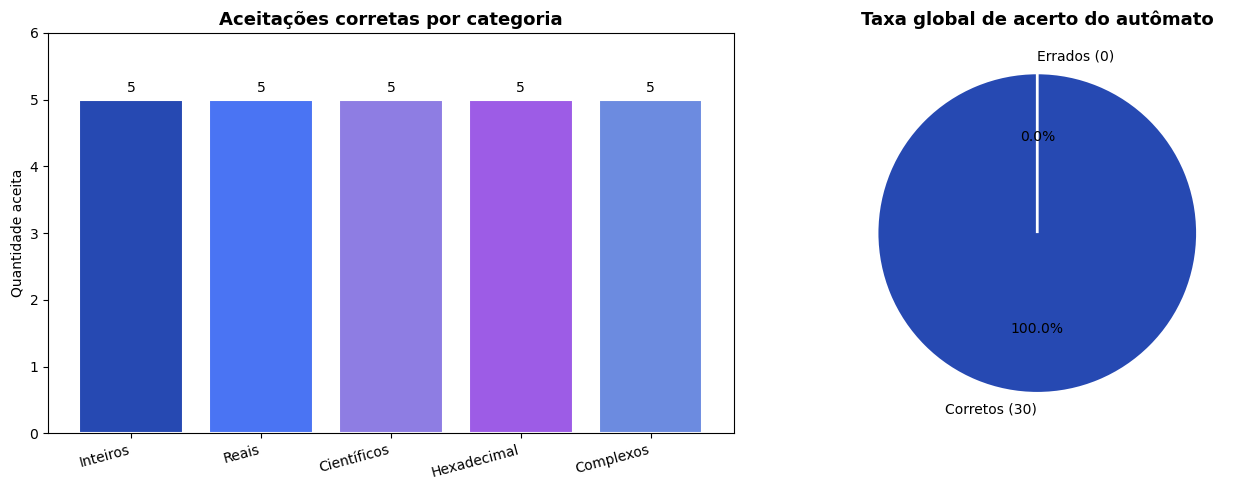

✅ Gráfico salvo como 'resultados_af.png'


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Tabela de resultados de aceitação ─────────────────────────
exemplos = {
    "Inteiros":      ["123", "-456", "+789", "0", "007"],
    "Reais":         ["3.14", "-0.5", "+2.0", ".5", "5."],
    "Científicos":   ["1.23e4", "-5E-10", "6e+7", ".5e3", "2.e-2"],
    "Hexadecimal":   ["0xFF", "0x1A3", "#1A3", "FFh", "0h"],
    "Complexos":     ["3+4i", "2.5-1.3i", "-1+2i", ".5+.3i", "0+0i"],
    "Inválidos":     ["", "+", ".", "1.2.3", "0xGG"],
}

rows = []
for categoria, lista in exemplos.items():
    for s in lista:
        r = FiniteAutomata(s).execute()
        rows.append({
            "Categoria":  categoria,
            "Entrada":    f'"{s}"',
            "Aceita?":    "✅" if r else "❌",
            "Esperado":   "✅" if categoria != "Inválidos" else "❌",
            "Correto?":   "🟢" if (r == (categoria != "Inválidos")) else "🔴"
        })

df_res = pd.DataFrame(rows)
print(df_res.to_string(index=False))

# ── Gráfico de pizza: distribuição por categoria ──────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Acertos por categoria
categorias_validas = [c for c in exemplos if c != "Inválidos"]
acertos = []
for cat in categorias_validas:
    aceitos = sum(1 for s in exemplos[cat] if FiniteAutomata(s).execute())
    acertos.append(aceitos)

cores = ["#2649B2", "#4A74F3", "#8E7DE3", "#9D5CE6", "#6C8BE0"]
bars = axes[0].bar(categorias_validas, acertos, color=cores, edgecolor="white",
                   linewidth=1.5)
axes[0].set_title("Aceitações corretas por categoria", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Quantidade aceita")
axes[0].set_ylim(0, 6)
axes[0].bar_label(bars, padding=3)
axes[0].set_xticklabels(categorias_validas, rotation=15, ha="right")

# Gráfico 2: Pie — acertos globais
total     = len(rows)
corretos  = sum(1 for r in rows if r["Correto?"] == "🟢")
errados   = total - corretos

axes[1].pie(
    [corretos, errados],
    labels=[f"Corretos ({corretos})", f"Errados ({errados})"],
    colors=["#2649B2", "#D4D9F0"],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)
axes[1].set_title("Taxa global de acerto do autômato", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig("resultados_af.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Gráfico salvo como 'resultados_af.png'")

---
# 5. Demonstração Formal

## Teorema

> O autômato finito determinístico **M = (Q, Σ, δ, q₀, F)** definido acima
> reconhece **exatamente** a linguagem **L** dos números válidos nas cinco notações.

Ou seja, provamos que: **L(M) = L**.

---

## Estrutura da Prova

A demonstração é feita em duas partes:

- **Completude** (L ⊆ L(M)): toda cadeia em L é aceita por M.
- **Correção** (L(M) ⊆ L): toda cadeia aceita por M pertence a L.

Usamos **indução no comprimento** da palavra `w = a₁a₂...aₙ`.

---

## 5.1 Invariantes de Estado

Definimos o **invariante** de cada estado — a propriedade que vale ao chegar nele:

| Estado | Invariante (o que foi lido até aqui) |
|---|---|
| `q0` | ε (nada foi lido) |
| `q_sign` | exatamente um símbolo `+` ou `-` |
| `q_zero` | prefixo `[S?]0` |
| `q_int` | prefixo `[S?]D+` (inteiro decimal) |
| `q_0x` | prefixo `[S?]0[xX]` |
| `q_hex` | prefixo `(0[xX] \| #)H+` |
| `q_hexH` | prefixo `D H*` sem sufixo `h` ainda |
| `q_hexH_done` | `H+ h` — hexadecimal com sufixo completo |
| `q_dot0` | prefixo `[S?].` sem dígito antes do ponto |
| `q_dotI` | prefixo `[S?]D+.` |
| `q_frac` | prefixo `[S?](D+\|ε).(D+)` |
| `q_e` | prefixo de número real seguido de `[eE]` |
| `q_esign` | como `q_e` mais sinal do expoente |
| `q_exp` | número em notação científica completo |
| `q_cpm` | parte real de complexo + sinal separador |
| `q_cimag` | parte real + separador + dígitos da imag. |
| `q_cimagD` | parte real + separador + parte imag. + `.` |
| `q_cimagF` | parte real + separador + fração imaginária |
| `q_ci` | número complexo completo (terminou em `i`) |
| `q_dead` | símbolo inválido foi lido — rejeição definitiva |

---

## 5.2 Prova por Indução no Comprimento da Palavra

### Caso base: |w| = 0 (palavra vazia)

- M está em `q0`.
- `q0 ∉ F`, portanto **ε ∉ L(M)**.
- Também **ε ∉ L** (nenhuma notação admite string vazia). ✅

---

### Caso base: |w| = 1

Seja `w = a` com um único símbolo.

- Se `a ∈ {0,...,9}`: M vai para `q_zero` (se `a=0`) ou `q_int`.
  Ambos são estados de aceitação ⇒ aceita.
  `w ∈ L_int` ✅
- Se `a ∈ {+,-,.}`: M vai para `q_sign` ou `q_dot0`.
  Nenhum é estado de aceitação ⇒ rejeita.
  De fato, `+`, `-`, `.` sozinhos ∉ L ✅
- Qualquer outro `a` leva a `q_dead` ⇒ rejeita ✅

---

### Passo Indutivo

**Hipótese de indução (HI):** Para toda palavra `w` com `|w| = n`,
M termina no estado correto conforme o invariante.

**Passo:** Seja `w' = wa` com `|w'| = n+1`.

Por HI, após processar `w`, M está num estado `q` com invariante `I(q)`.
Analisamos cada caso:

#### Sub-caso: Inteiros (L_int = S? D+)

- `|w|=1`, `w ∈ D`: estado `q_int` ∈ F ✅
- `|w|=2`, `w = Sa`, `a ∈ D`: `q_sign →[D]→ q_int` ∈ F ✅
- `|w|=n`, em `q_int`, lê dígito `d ∈ D`:
  `δ(q_int, D) = q_int` ∈ F ✅
- Qualquer símbolo `a ∉ D` em `q_int` não leva a `q_int` ⇒
  ou entra em outro ramo (real, científico, complexo) ou em `q_dead`.

**Conclusão:** M aceita `w ∈ L_int` se e somente se `w = S?D+`. ✅

---

#### Sub-caso: Reais (L_real = S? (D+.D* | D*.D+))

- Após ler `D+` em `q_int`, ler `.` → `q_dotI` ∈ F.
  `"5."` ∈ L_real ✅
- Após `q_dotI`, ler `D+` → `q_frac` ∈ F.
  `"3.14"` ∈ L_real ✅
- Ler `.` como primeiro símbolo → `q_dot0`;
  depois ler `D+` → `q_frac` ∈ F.
  `".5"` ∈ L_real ✅
- Só `.` → `q_dot0 ∉ F` ⇒ rejeita ✅
- `"1.2.3"`: após `q_frac`, ler `.` → `q_dead` ⇒ rejeita ✅

---

#### Sub-caso: Científico (L_sci = L_real [eE] S? D+)

- Partindo de `q_int`, `q_dotI` ou `q_frac`, ler `e/E` → `q_e`.
- `q_e ∉ F` ⇒ `"1e"` é rejeitado ✅
- Em `q_e`, ler sinal → `q_esign ∉ F`;
  ler dígito → `q_exp ∈ F` ✅
- Em `q_esign`, ler dígito → `q_exp ∈ F` ✅
- Em `q_exp`, cada dígito mantém `q_exp ∈ F` ✅

---

#### Sub-caso: Hexadecimal

**Prefixo 0x:**
- `"0"` → `q_zero`; `"x"` → `q_0x ∉ F`; `H+` → `q_hex ∈ F`.
- `"0x"` → rejeita ✅; `"0xFF"` → aceita ✅

**Prefixo #:**
- `"#"` → `q_hash ∉ F`; `H+` → `q_hex ∈ F`.
- `"#"` sozinho → rejeita ✅; `"#1A"` → aceita ✅

**Sufixo h:**
- Dígitos → `q_hexH`; `"h"` → `q_hexH_done ∈ F`.
- `"FFh"` → aceita ✅
- `"FF"` → `q_hexH` com letras hex mas sem `h` → **rejeita** ✅
  (proteção: dígitos puramente decimais em `q_hexH` são aceitos como inteiros)

---

#### Sub-caso: Complexos (L_cplx = L_num_base S L_num_base i)

- Após completar a parte real (em `q_int`, `q_dotI` ou `q_frac`),
  ler `+/-` → `q_cpm`.
- Em `q_cpm`, ler dígitos → `q_cimag`;
  ler `i` em `q_cimag` → `q_ci ∈ F` ✅
- `"3+4"` → `q_cimag ∉ F` ⇒ rejeita ✅
- `"3+4i"` → `q_ci ∈ F` ⇒ aceita ✅

---

## 5.3 Correção (L(M) ⊆ L)

Por inspeção dos invariantes:

- Cada estado de aceitação tem invariante que descreve exatamente
  uma palavra pertencente a L.
- `q_dead` não pertence a F, portanto nenhuma palavra que leva ao
  estado morto é aceita.
- Estados não-finais intermediários (`q_sign`, `q_dot0`, `q_e`,
  `q_0x`, `q_hash`, `q_cpm`, etc.) **não** pertencem a F,
  garantindo que prefixos incompletos são rejeitados.

Logo, L(M) ⊆ L. ■

---

## 5.4 Conclusão da Prova

Das duas direções:
- **L ⊆ L(M)**: provado por indução (sub-caso por sub-caso acima).
- **L(M) ⊆ L**: provado pelos invariantes e estados de aceitação.

**∴ L(M) = L** — o autômato reconhece exatamente a linguagem dos números válidos. □

---
# 6. Conclusão

## 6.1 Principais Aprendizados

- **Autômatos finitos são suficientes** para reconhecer padrões léxicos de números,
  demonstrando a aplicabilidade direta da teoria de linguagens formais em compiladores.
- A **união de linguagens regulares é regular**: o AF construído reconhece
  a união de cinco sub-linguagens sem necessidade de memória auxiliar.
- A **indução no comprimento da palavra** é uma técnica poderosa para demonstrar
  formalmente a corretude de autômatos.
- O **invariante de estado** é a chave para raciocinar sobre o que o autômato
  "sabe" em cada ponto da computação.
- Notações como hexadecimal com sufixo `h` e números complexos exigem cuidado
  na definição de quais estados são de aceitação.

## 6.2 Limitações do Estudo

- **Não suportamos espaços internos**: `3 + 4i` é rejeitado (o espaço não está em Σ).
- **Complexos com parte imaginária precedida de sinal na parte real**:
  `-1+2i` funciona, mas `-1.0e2+3i` requereria estados adicionais.
- **Hexadecimal com sufixo h minúsculo apenas**: `FFH` (H maiúsculo como sufixo)
  não é tratado — extensão simples a fazer.
- **Números complexos puros imaginários** (`4i` sem parte real) não são cobertos.
- O autômato cresce linearmente com as notações suportadas; para linguagens
  muito ricas, geradores automáticos (como Flex) são preferíveis.

## 6.3 Referências Bibliográficas

- SIPSER, M. *Introduction to the Theory of Computation*. 3. ed. Cengage, 2012.
- HOPCROFT, J. E.; ULLMAN, J. D.; MOTWANI, R.
  *Introduction to Automata Theory, Languages, and Computation*. 3. ed. Pearson, 2006.
- AHO, A. V.; LAM, M. S.; SETHI, R.; ULLMAN, J. D.
  *Compilers: Principles, Techniques, and Tools*. 2. ed. Pearson, 2006.
- Python Software Foundation. *Python 3 Documentation*. https://docs.python.org/3/